In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

In [2]:
# Create a simple toy dataset
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
pass_exam = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

toy_df = pd.DataFrame(
    {"hours_studied": hours_studied.flatten(), "pass_exam": pass_exam}
)

toy_df

,hours_studied,pass_exam
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1


In [3]:
toy_model = LogisticRegression()
toy_model.fit(hours_studied, pass_exam)

print("Intercept (b):", toy_model.intercept_)
print("Coefficient (m):", toy_model.coef_)

Intercept (b): [-5.29559243]
Coefficient (m): [[1.17808562]]


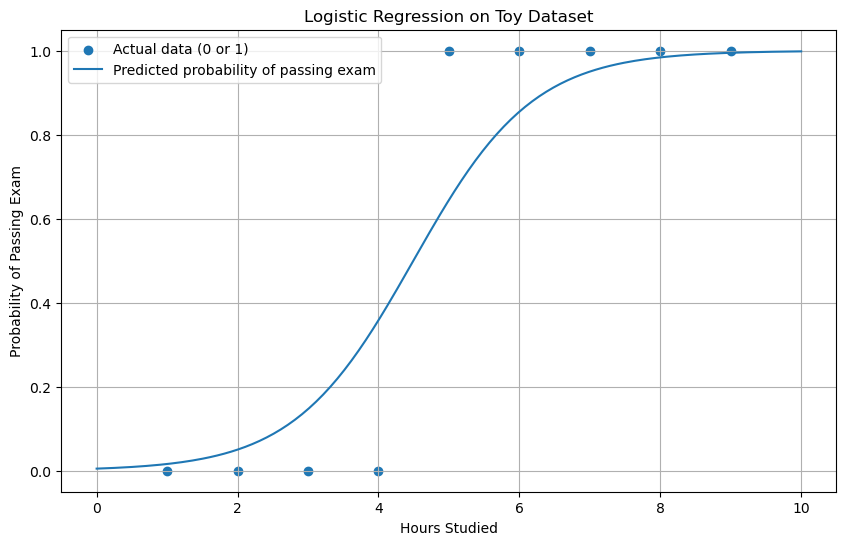

In [4]:
hours_grid = np.linspace(0, 10, 200).reshape(-1, 1)
pass_prob = toy_model.predict_proba(hours_grid)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    hours_studied,
    pass_exam,
    label="Actual data (0 or 1)"
)
plt.plot(
    hours_grid,
    pass_prob,
    label = "Predicted probability of passing exam",
)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing Exam")
plt.title("Logistic Regression on Toy Dataset")
plt.legend()
plt.grid(True)

In [5]:
example_hours = np.array([[2], [4], [6], [8]])
example_probs = toy_model.predict_proba(example_hours)[:, 1]
example_pred = toy_model.predict(example_hours)

results_df = pd.DataFrame({
    "hours_studied": example_hours.flatten(),
    "predicted_probability": np.round(example_probs, 4),
    "predicted_class": example_pred 
})

results_df

,hours_studied,predicted_probability,predicted_class
0,2,0.0502,0
1,4,0.3582,0
2,6,0.8548,1
3,8,0.9842,1
